### Synthetic Banking Customer Dataset (80,000 Records)

---
## İmports

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import joblib
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (classification_report, roc_auc_score,
                             f1_score, confusion_matrix, 
                             precision_recall_curve, RocCurveDisplay)
import warnings
warnings.filterwarnings('ignore')

---
## Load Data

In [139]:
# Load the dataset
main_df = pd.read_csv('../data/vietnam_bank_churn_dataset.csv')

# Display the first few rows of the dataset

with pd.option_context('display.max_columns', None):
    display(main_df.head())

,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,tenure_ye,married,nums_card,nums_service,active_member,last_active_date,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,0,2,4,8,True,03/04/2025,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,3,1,3,2,True,14/05/2025,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,4,0,2,8,False,10/09/2021,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4
3,4,Dương Trần Nhiên,766,male,44,Chủ Doanh nghiệp nhỏ,50615501,79000000,Phường 7 (Q7),TP. Hồ Chí Minh,3,0,4,3,False,04/03/2025,0,12/02/2022,False,Priority,23,Bronze,offline,0.2185,Low,4
4,5,Dương Thu Linh,677,female,77,Giáo viên/Giảng viên,40532432,25000000,Phường Thắng Lợi (Q10),TP. Hồ Chí Minh,2,1,4,3,False,06/08/2022,0,24/07/2022,False,Emerging,23,Bronze,offline,0.2942,Low,2


In [140]:
# Assigning df to main_df copy for after looking at the orginal data
df = main_df.copy()

# Print dataset shape and memory usage
print(f"Dataset shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Memory usage: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

Dataset shape: 80,000 rows × 26 columns
Memory usage: 76.46 MB


In [141]:
# Look first few rows of the data
df.head(3)

,id,full_name,credit_sco,gender,age,occupation,balance,monthly_ir,address,origin_province,...,last_transaction_month,created_date,exit,customer_segment,engagement_score,loyalty_level,digital_behavior,risk_score,risk_segment,cluster_group
0,1,Đặng Văn Vũ,725,male,55,Chủ Doanh nghiệp nhỏ,177306004,121000000,Phường An Hội (BT),TP. Hồ Chí Minh,...,91038993,27/02/2025,False,Priority,90,Bronze,mobile,0.0359,Low,4
1,2,Bùi Hữu Phúc,689,male,45,Nội trợ/Sinh viên,1927416,5000000,Phường Bến Thành (Q1),Đồng Nai,...,3255569,29/07/2021,False,Mass,63,Gold,mobile,0.2664,Low,2
2,3,Lê Văn Mai,702,female,44,Chủ Doanh nghiệp nhỏ,304931745,109000000,Phường Hòa Bình (Q11),TP. Hồ Chí Minh,...,0,03/03/2021,False,Priority,36,Silver,offline,0.1343,Low,4


In [142]:
# Get information about the dataset(number of rows, columns, data types, etc.)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 26 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      80000 non-null  int64  
 1   full_name               80000 non-null  object 
 2   credit_sco              80000 non-null  int64  
 3   gender                  80000 non-null  object 
 4   age                     80000 non-null  int64  
 5   occupation              80000 non-null  object 
 6   balance                 80000 non-null  int64  
 7   monthly_ir              80000 non-null  int64  
 8   address                 80000 non-null  object 
 9   origin_province         80000 non-null  object 
 10  tenure_ye               80000 non-null  int64  
 11  married                 80000 non-null  int64  
 12  nums_card               80000 non-null  int64  
 13  nums_service            80000 non-null  int64  
 14  active_member           80000 non-null

- There is 80000 row, 22 column and there is no missing value
- Types is integer, float, object and boolen.
- There is object type date column ('last_active_date')
- There is features like engagement score, customer segment etc. calculated based on data we will remove them beacause in real world data, its not to be.
- Also id like columns and not essential ones, we will drop them also

In [143]:
# Get summary statistics of the dataset
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,80000.0,4.000050e+04,2.309416e+04,1.000000e+00,2.000075e+04,4.000050e+04,6.000025e+04,8.000000e+04
credit_sco,80000.0,6.843211e+02,5.116973e+01,4.950000e+02,6.490000e+02,6.820000e+02,7.180000e+02,8.000000e+02
age,80000.0,4.938186e+01,1.506748e+01,2.000000e+01,3.800000e+01,4.700000e+01,5.800000e+01,9.000000e+01
balance,80000.0,6.118320e+07,8.868620e+07,4.086630e+05,1.462592e+07,3.090276e+07,6.960994e+07,1.000000e+09
monthly_ir,80000.0,3.778820e+07,3.655107e+07,3.000000e+06,1.400000e+07,2.300000e+07,4.700000e+07,2.160000e+08
tenure_ye,80000.0,1.777250e+00,1.315828e+00,0.000000e+00,1.000000e+00,2.000000e+00,3.000000e+00,4.000000e+00
married,80000.0,9.708250e-01,6.946977e-01,0.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,3.000000e+00
nums_card,80000.0,2.634688e+00,1.218556e+00,1.000000e+00,2.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00
nums_service,80000.0,3.564425e+00,2.002448e+00,1.000000e+00,2.000000e+00,3.000000e+00,5.000000e+00,8.000000e+00
last_transaction_month,80000.0,8.831755e+06,3.378683e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000e+08


- **balance:** highly skewed, there are extreme outliers

- **monthly income:** highly skewed, some customers carry very large income

- **tenure years** relatively short customer relationships.

- **number of cards** most customers hold 2–3 cards.

- **number of servicesL:** customers typically use multiple services.

- **last transaction month** many customers haven’t transacted recently, there is values up to 600 million (likely data errors). we will drop this column.

In [144]:
# Check if null values
df.isnull().sum().sum()

np.int64(0)

In [145]:
# Check duplicated values
df.duplicated().sum()

np.int64(0)

---
## Rename Columns

Orginal column names have short names. For easy referenece and readablity we will rename them.

In [146]:
# Look column names
df.columns


Index(['id', 'full_name', 'credit_sco', 'gender', 'age', 'occupation',
       'balance', 'monthly_ir', 'address', 'origin_province', 'tenure_ye',
       'married', 'nums_card', 'nums_service', 'active_member',
       'last_active_date', 'last_transaction_month', 'created_date', 'exit',
       'customer_segment', 'engagement_score', 'loyalty_level',
       'digital_behavior', 'risk_score', 'risk_segment', 'cluster_group'],
      dtype='object')

In [147]:
# Assign new column names to column_map as a dictionary
column_map ={'credit_sco': 'credit_score',
            'occupation': 'profession',
            'monthly_ir': 'monthly_income',
            'tenure_ye': 'tenure_yearly'
}

# Rename some columns
df = df.rename(columns = column_map)

# Data Cleaning

---
## Data Type Fixes

In [148]:
# Convert date column from object to datetime
df['last_active_date'] = pd.to_datetime(df['last_active_date'], format= 'mixed')
df['created_date'] = pd.to_datetime(df['created_date'], format =  'mixed')

# Show data types
print('Dtypes:')
print(df.dtypes)

Dtypes:
id                                 int64
full_name                         object
credit_score                       int64
gender                            object
age                                int64
profession                        object
balance                            int64
monthly_income                     int64
address                           object
origin_province                   object
tenure_yearly                      int64
married                            int64
nums_card                          int64
nums_service                       int64
active_member                       bool
last_active_date          datetime64[ns]
last_transaction_month             int64
created_date              datetime64[ns]
exit                                bool
customer_segment                  object
engagement_score                   int64
loyalty_level                     object
digital_behavior                  object
risk_score                       float64
risk_seg

# Drop choosen cols

In [149]:
# Assign column names to new variable which will be dropped
drop_cols = ['id', 'full_name','gender', 'address', 
            'engagement_score', 'loyalty_level', 'risk_score', 
            'risk_segment', 'cluster_group', 'last_transaction_month']

# Drop choosen columns
df = df.drop(drop_cols, axis=1)

---
# EDA 

### Dividing columns to categoric and numeric 

In [150]:
cat_cols = df.select_dtypes(include='object')

num_cols = df.select_dtypes(exclude='object')

### Unique value check

In [151]:
# Create loop for displaying unique values of each categoric column
for col in cat_cols:
    print('Column name:', df[col].name)
    print('Number of unique:' ,df[col].nunique())
    print('Values:')
    print(df[col].unique())
    print('-'*85)

Column name: profession
Number of unique: 10
Values:
['Chủ Doanh nghiệp nhỏ' 'Nội trợ/Sinh viên' 'Giáo viên/Giảng viên'
 'Kỹ sư/Chuyên viên IT' 'Hưu trí' 'Nhân viên văn phòng/Công chức'
 'Kinh doanh/Bán hàng' 'Quản lý/Lãnh đạo' 'Kế toán/Tài chính'
 'Lao động phổ thông']
-------------------------------------------------------------------------------------
Column name: origin_province
Number of unique: 9
Values:
['TP. Hồ Chí Minh' 'Đồng Nai' 'Bình Dương' 'Tỉnh khác' 'Hà Nội' 'Long An'
 'Bà Rịa - Vũng Tàu' 'Cần Thơ' 'Tiền Giang']
-------------------------------------------------------------------------------------
Column name: customer_segment
Number of unique: 4
Values:
['Priority' 'Mass' 'Emerging' 'Affluent']
-------------------------------------------------------------------------------------
Column name: digital_behavior
Number of unique: 2
Values:
['mobile' 'offline']
-------------------------------------------------------------------------------------


- We will replace profession column with translated version
- And converted last_activate_date to datetime

In [152]:
# Mapping profession names for understanding
df['profession'] = df['profession'].map({'Chủ Doanh nghiệp nhỏ': 'Small Business Owner',
                       'Nội trợ/Sinh viên': 'Housewife/Student',
                       'Giáo viên/Giảng viên': 'Teacher/Lecturer',
                       'Kỹ sư/Chuyên viên IT': 'Engineer/IT Specialist',
                       'Hưu trí': 'Retired',
                       'Nhân viên văn phòng/Công chức': 'Office Worker/Civil Servant',
                       'Kinh doanh/Bán hàng': 'Business/Salesperson',
                       'Quản lý/Lãnh đạo': 'Manager/Leader',
                       'Kế toán/Tài chính': 'Accountant/Finance Worker',
                       'Lao động phổ thông': 'General Laborer'
                       })

In [153]:
for col in num_cols:
    print('Column name:', df[col].name)
    print('Number of unique:' ,df[col].nunique())
    print('Values:')
    print(df[col].unique())
    print('-'*85)

Column name: credit_score
Number of unique: 291
Values:
[725 689 702 766 677 708 690 728 711 724 679 611 584 788 747 734 721 644
 695 684 654 638 743 641 732 685 649 714 739 704 663 757 740 642 694 651
 634 621 659 710 674 669 658 568 675 718 630 650 633 701 768 632 664 606
 661 645 692 709 730 712 612 628 680 761 656 665 782 800 754 617 639 785
 615 762 748 657 626 673 707 741 752 655 676 699 729 698 643 703 688 609
 652 713 723 767 682 678 686 646 770 613 716 697 672 648 706 731 636 629
 700 717 681 705 727 653 760 560 647 722 745 592 789 627 662 696 736 599
 765 744 585 575 720 779 620 624 737 614 799 616 691 726 671 625 683 670
 668 742 567 637 660 618 790 583 591 749 797 784 667 755 693 607 751 666
 733 594 771 746 719 776 735 796 715 604 635 781 622 780 640 598 619 572
 764 587 597 576 787 569 593 623 777 758 631 750 596 687 756 775 595 605
 602 588 516 600 753 738 554 553 774 791 581 759 577 608 778 773 610 556
 571 793 601 548 795 534 582 536 559 589 798 579 555 590 561 603 586

- exit and actice member column is boolen we can encode it with using map function.

# Target check

Check churn imbalance

In [154]:
# Value counts of 'churn' column
value_counts = df['exit'].value_counts()

# Imbalance ratio (minority / majority)
print('_'*40)
imbalance_ratio = value_counts.min() / value_counts.max()
print("Imbalance Ratio:", round(imbalance_ratio, 2))
print('_'*40)

# Percentage of values
percentage = value_counts / len(df['exit'])
print("Class percent (%):\n", (round(percentage, 2)*100).astype(int).astype(str)+' %')

________________________________________
Imbalance Ratio: 0.22
________________________________________
Class percent (%):
 exit
False    82 %
True     18 %
Name: count, dtype: object


### Target distribution

Text(0.5, 1.0, 'Churn percentage')

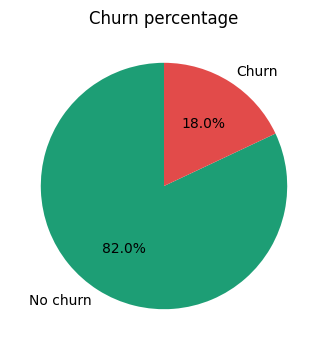

In [155]:
# Assign Churn value counts to variable counts and create labels and colors for the charts
counts =   df['exit'].value_counts()
labels = ['No churn', 'Churn']

# Create size of figure
plt.figure(figsize=(16,4))

# Pie chart
plt.pie(counts, labels=labels, autopct='%1.1f%%', colors=['#1D9E75', '#E24B4A'], startangle=90)
plt.title('Churn percentage')


- There is imbalance in target feature - about 82 % of customers not churn(didn't exited) 
- We have to use additional metrics(presicion, recall etc.) for checking accuracy of model.

# Feature Analysis

Dividing feature for analysis

In [156]:
target = 'exit'

num_cols = [
    'credit_score','age', 'balance', 'monthly_income', 
    'tenure_yearly', 'nums_card', 'nums_service'
]

cat_cols = [
    'profession', 'origin_province', 'married', 'active_member', 'digital_behavior'
]

date_cols = ['last_active_date', 'created_date']

## Numerical Feature Analysis

In [157]:
# Get summary statistics of the dataset
df.describe().T

,count,mean,min,25%,50%,75%,max,std
credit_score,80000.0,684.321137,495.0,649.0,682.0,718.0,800.0,51.169733
age,80000.0,49.381862,20.0,38.0,47.0,58.0,90.0,15.06748
balance,80000.0,61183195.39705,408663.0,14625918.25,30902758.0,69609941.25,1000000000.0,88686198.425266
monthly_income,80000.0,37788200.0,3000000.0,14000000.0,23000000.0,47000000.0,216000000.0,36551066.202171
tenure_yearly,80000.0,1.77725,0.0,1.0,2.0,3.0,4.0,1.315828
married,80000.0,0.970825,0.0,1.0,1.0,1.0,3.0,0.694698
nums_card,80000.0,2.634688,1.0,2.0,2.0,3.0,5.0,1.218556
nums_service,80000.0,3.564425,1.0,2.0,3.0,5.0,8.0,2.002448
last_active_date,80000,2024-05-21 11:40:43.320000,2021-01-03 00:00:00,2023-10-06 00:00:00,2024-08-20 00:00:00,2025-03-23 00:00:00,2025-12-06 00:00:00,NaN
created_date,80000,2023-04-06 01:44:25.079999744,2021-01-01 00:00:00,2022-02-17 00:00:00,2023-04-03 00:00:00,2024-05-17 00:00:00,2025-12-06 00:00:00,NaN


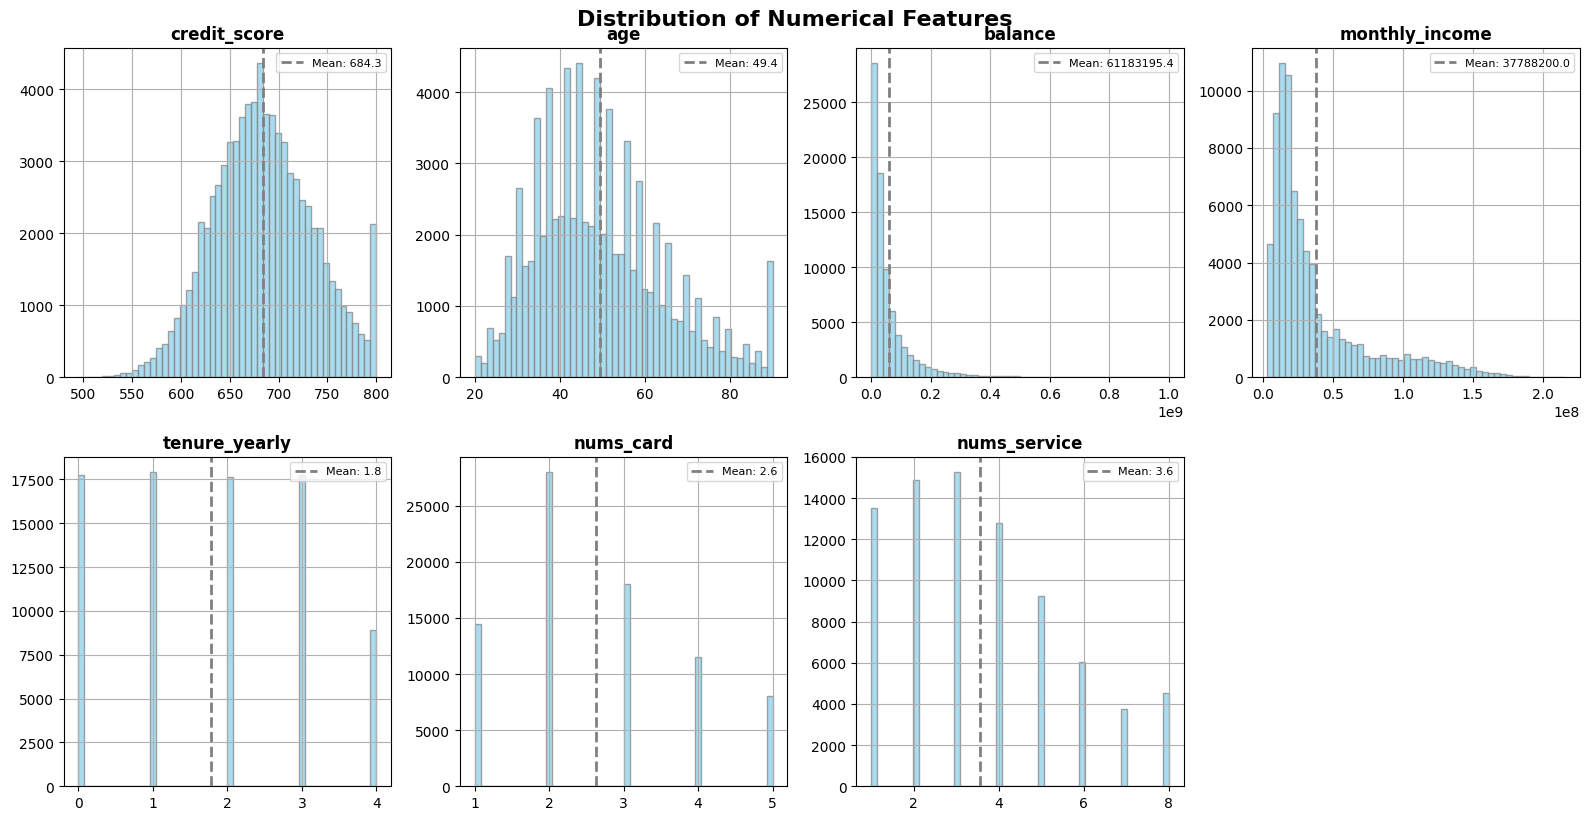

In [158]:
# Create subplots for numerical features
fig, axes = plt.subplots(3, 4, figsize=(16, 12))
axes = axes.ravel()

for idx, col in enumerate(num_cols):
    df[col].hist(bins=50, ax=axes[idx], edgecolor='gray', alpha=0.7, color= 'skyblue')
    axes[idx].set_title(f'{col}', fontsize=12, fontweight='bold')
    axes[idx].axvline(df[col].mean(), color='gray', linestyle='--', 
                        linewidth=2, label=f'Mean: {df[col].mean():.1f}')
    axes[idx].legend(fontsize=8)

for i in range(1,6):
    fig.delaxes(axes[-1*i])

plt.tight_layout()
plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.001)
plt.show()

# Categorical Feature Analysis

In [159]:
print(f"Categorical features: {len(cat_cols)}\n")
for col in cat_cols:
    n_unique = df[col].nunique()
    print(f"  === {col:15} : {n_unique:2} unique values")

Categorical features: 5

  === profession      : 10 unique values
  === origin_province :  9 unique values
  === married         :  4 unique values
  === active_member   :  2 unique values
  === digital_behavior :  2 unique values


### Categorical Distribution Visualizations

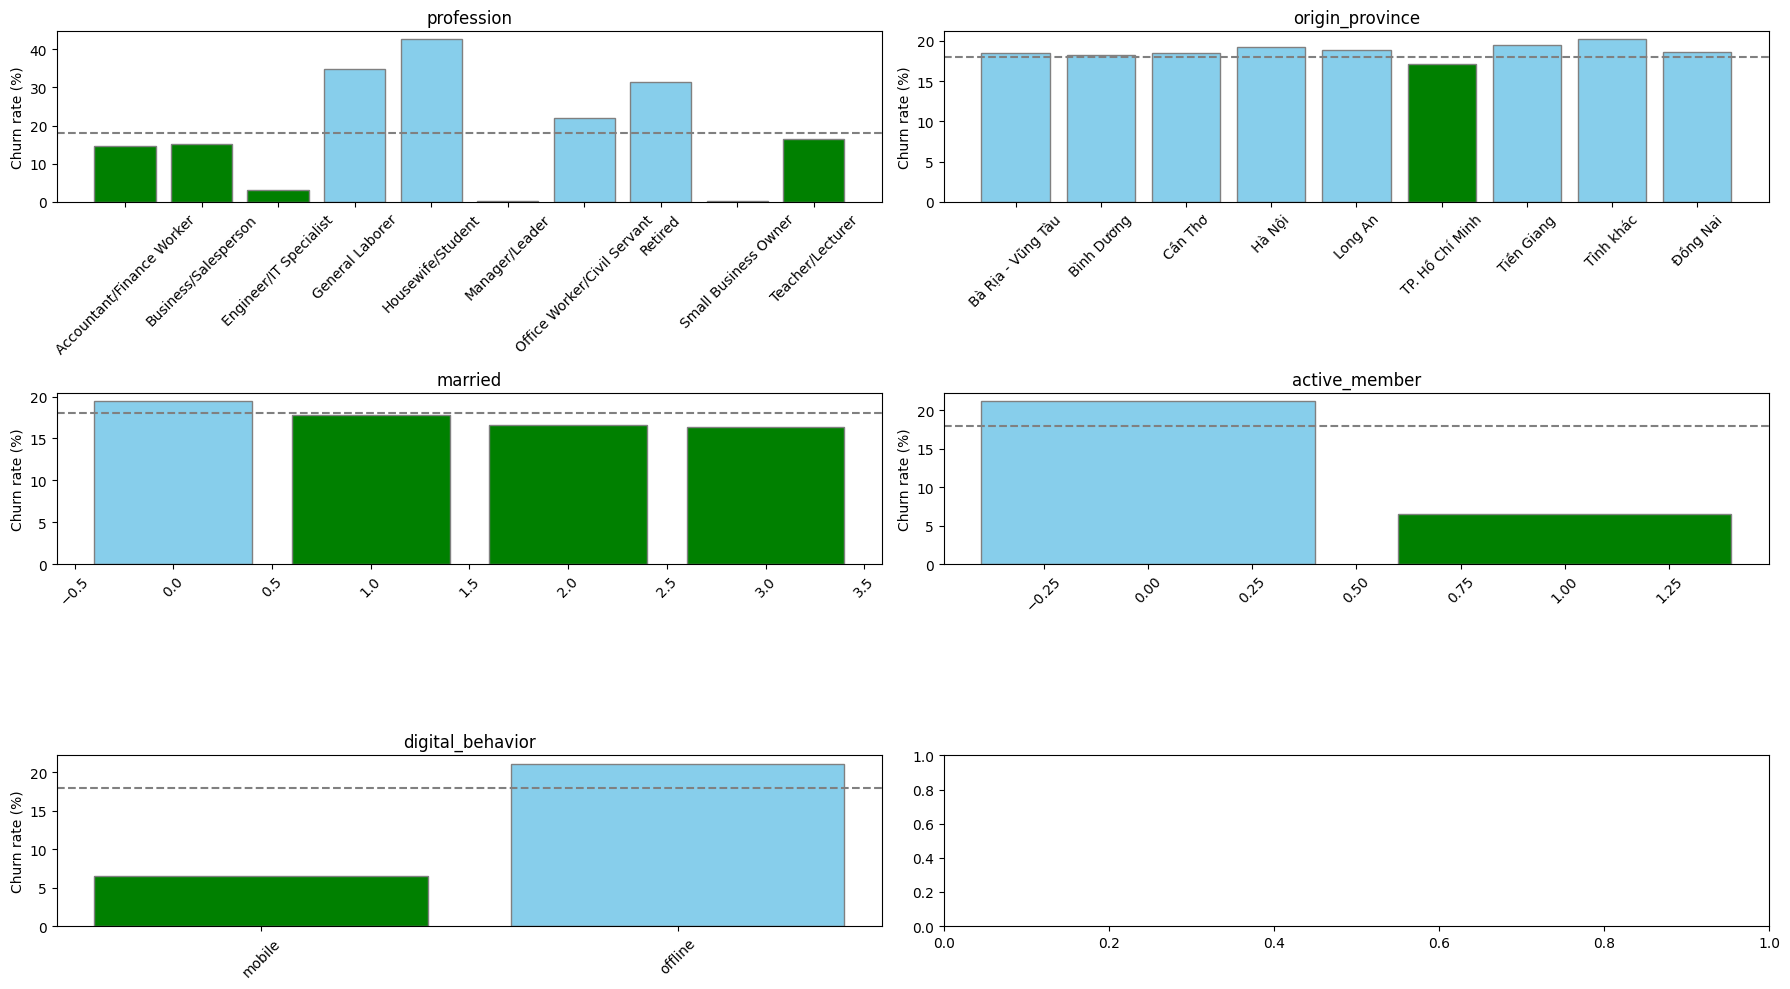

In [160]:
fig, axes = plt.subplots(3, 2, figsize=(18, 10))
axes = axes.flatten()

avg_churn = df[target].mean() * 100

for i, col in enumerate(cat_cols):
    churn_rate = df.groupby(col)[target].mean() * 100
    colors = ['skyblue' if x > avg_churn else 'green' for x in churn_rate.values]
    axes[i].bar(churn_rate.index, churn_rate.values, color=colors, edgecolor = 'gray',)
    axes[i].axhline(avg_churn, color='gray', linestyle='--')
    axes[i].set_title(col)
    axes[i].set_ylabel('Churn rate (%)')
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


### Correlation Analysis

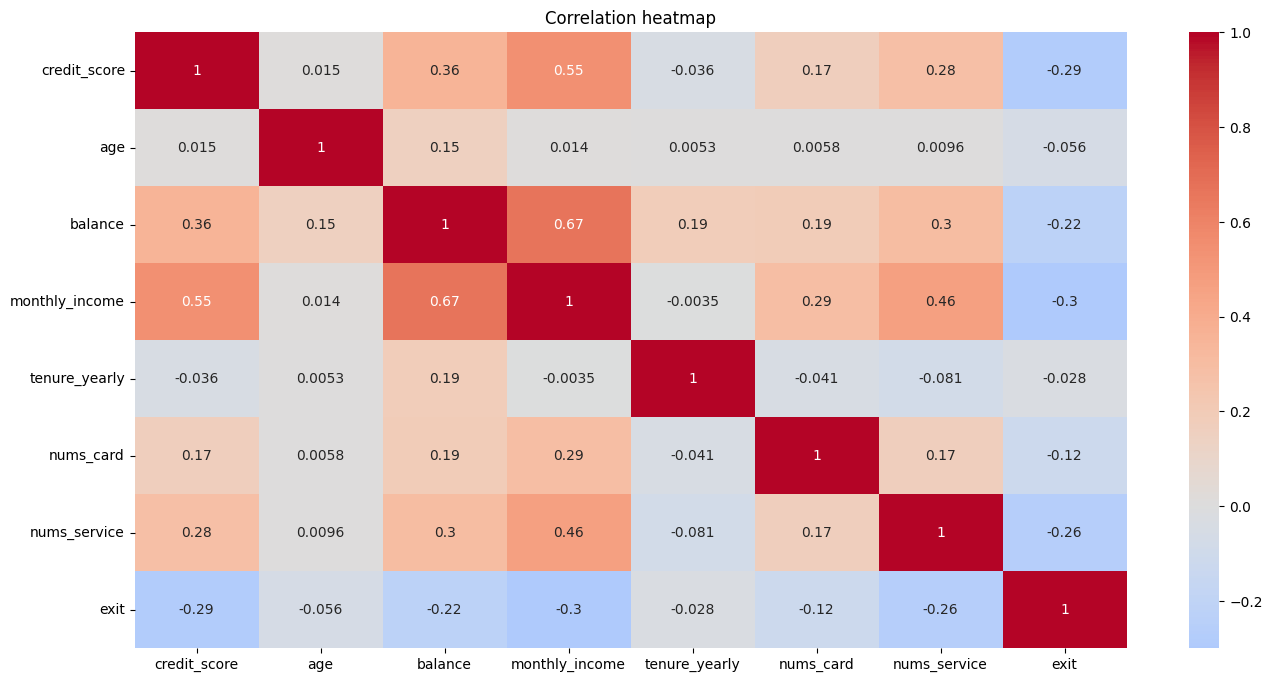

In [161]:
corr = df[num_cols + [target]].corr()

plt.figure(figsize=(16, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

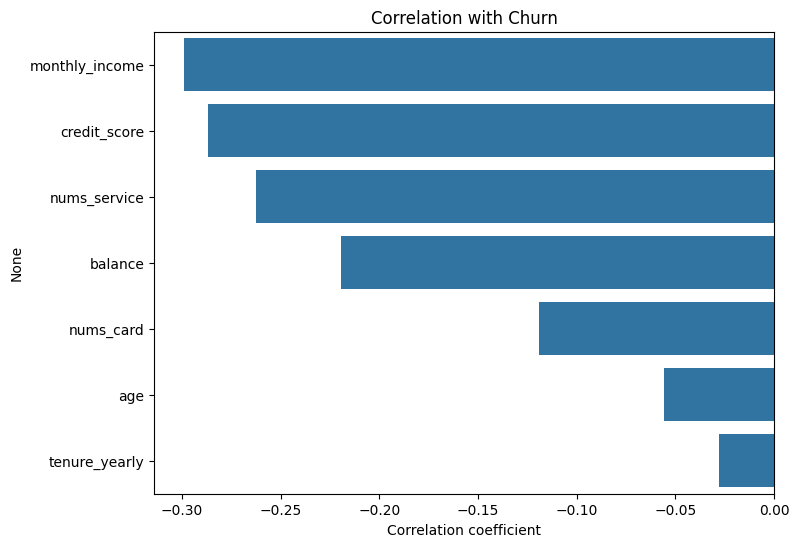

In [162]:
num_cols = ['credit_score','age', 'balance', 'monthly_income', 'tenure_yearly', 'nums_card', 'nums_service', 'exit']
# Korrelyasiya yalnız churn ilə
corr = df[num_cols].corr()['exit'].sort_values(ascending= True).drop('exit')

plt.figure(figsize=(8, 6))
sns.barplot(x=corr.values, y=corr.index)
plt.title("Correlation with Churn")
plt.xlabel("Correlation coefficient")
plt.show()


### Feature Analysis by Target

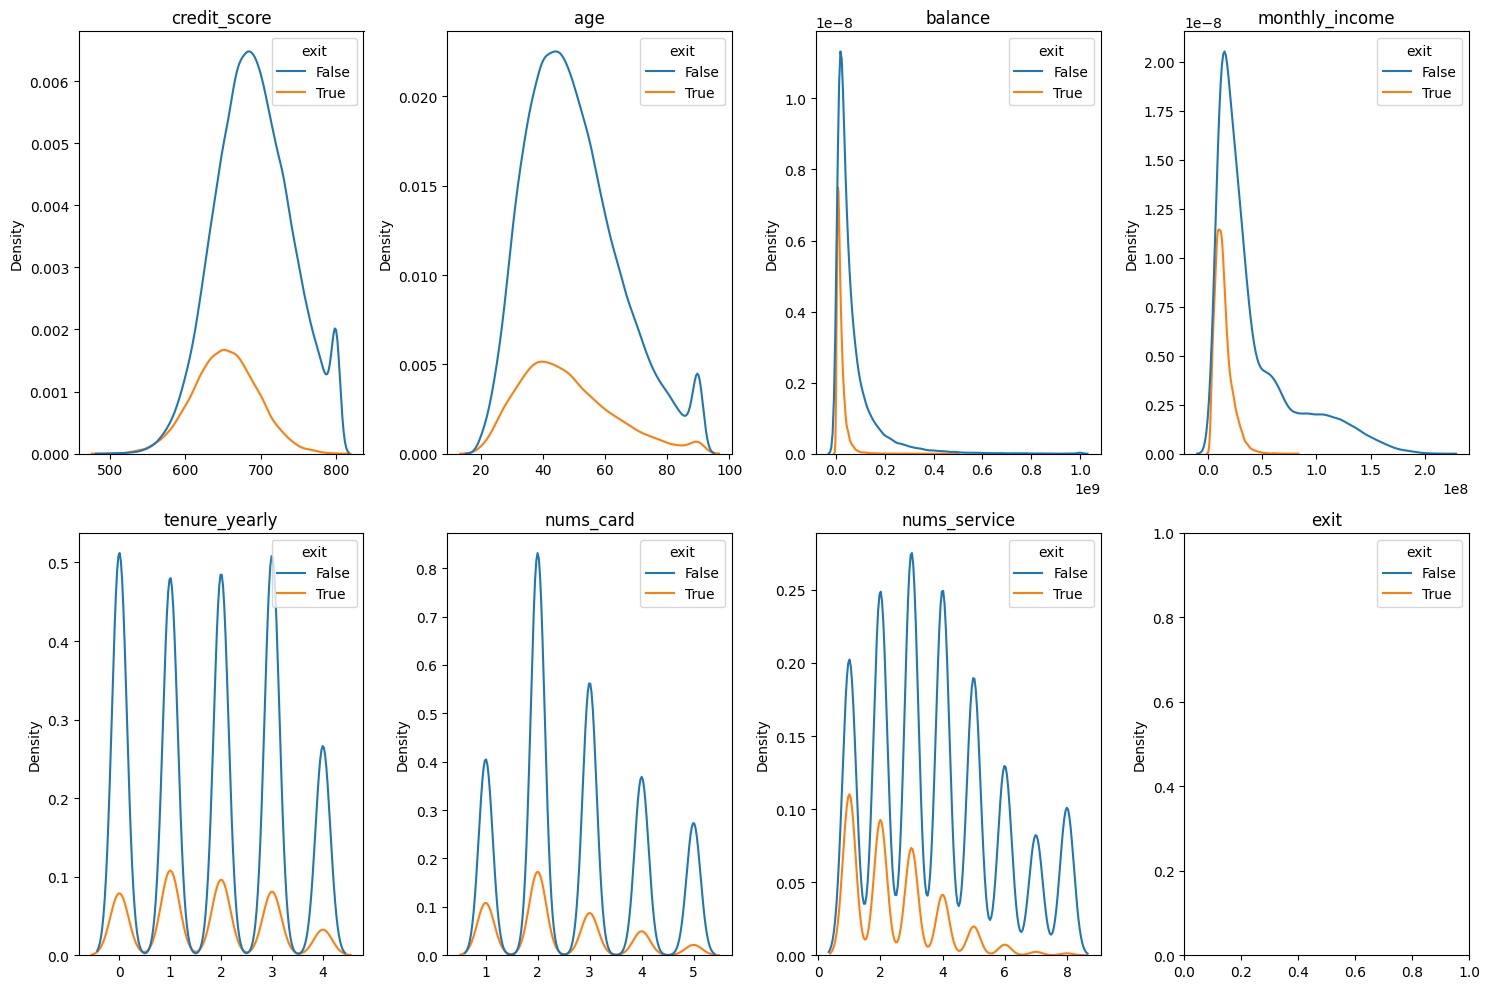

In [163]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.kdeplot(data=df, x=col, hue=target, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Density')

plt.tight_layout()
plt.show()


- We can see here credit score and age have more differenciation in case of not churn
- Also where customer has high monthly income and balance they are not exited

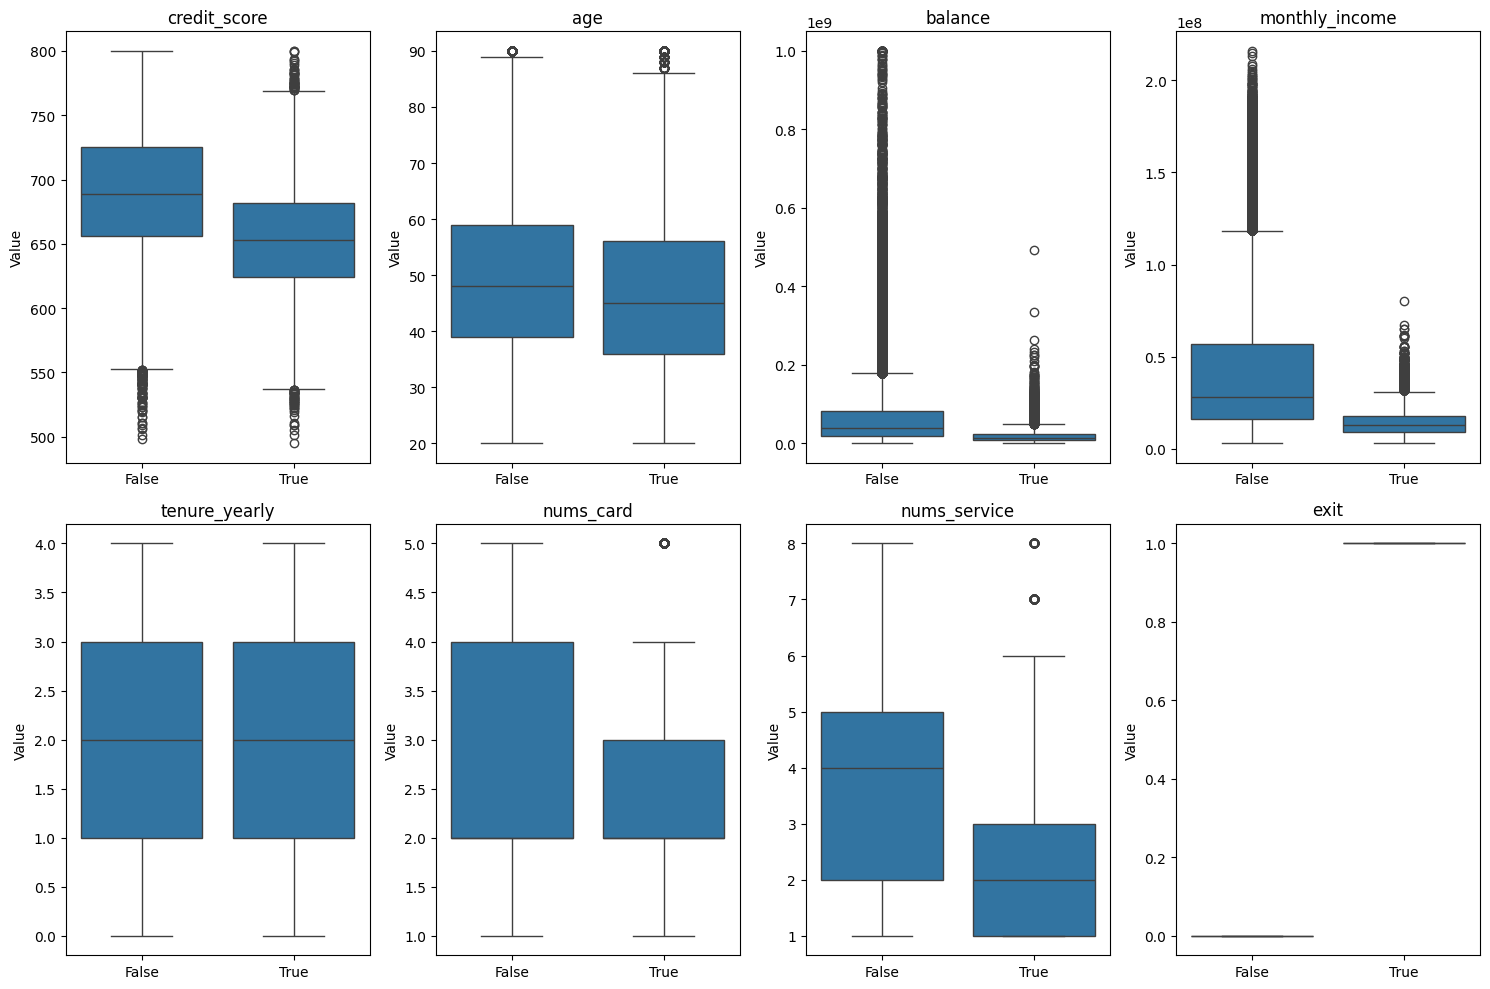

In [164]:
fig, axes = plt.subplots(2, 4, figsize=(15, 10))
axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(data=df, x=target, y=col, ax=axes[i])
    axes[i].set_title(col)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Value')

plt.tight_layout()
plt.show()


# Data Preprocessesing

Encode with map: Convert exit, active member and digital behavior column to 0 and 1 with using map

In [165]:
df['exit'] = df['exit'].map({True:1, False:0})
df['active_member'] = df['active_member'].map({True:1, False:0})
df['digital_behavior'] = df['digital_behavior'].map({'mobile':1, 'offline':0})

In [166]:
# balance_log for outliers
df["balance"] = np.log1p(df["balance"])


## Feature Engineering

Create recency column from last active date

In [167]:
# crate max date from dataset
max_date = df['last_active_date'].max()

# Create reference date: max_date + 1 day
reference_date = max_date + pd.Timedelta(days=1)

# Recency calculation
df['recency_days'] = (reference_date - df['last_active_date']).dt.days

In [168]:
# Calculating account age from created date
df['account_age_days'] = (max_date - df['created_date']).dt.days

# Create created month and weekdayg columns
df['created_month'] = df['created_date'].dt.month
df['created_weekday'] = df['created_date'].dt.weekday 

# Grouping for account age 
df['account_age_groups'] = pd.cut(df['account_age_days'],
                                  bins=[0, 180, 365, 730, 9999],
                                  labels=['<6m', '6-12m', '1-2y', '2y+'])


In [169]:
df.dtypes

credit_score                   int64
age                            int64
profession                    object
balance                      float64
monthly_income                 int64
origin_province               object
tenure_yearly                  int64
married                        int64
nums_card                      int64
nums_service                   int64
active_member                  int64
last_active_date      datetime64[ns]
created_date          datetime64[ns]
exit                           int64
customer_segment              object
digital_behavior               int64
recency_days                   int64
account_age_days               int64
created_month                  int32
created_weekday                int32
account_age_groups          category
dtype: object

### Check if there relation with target

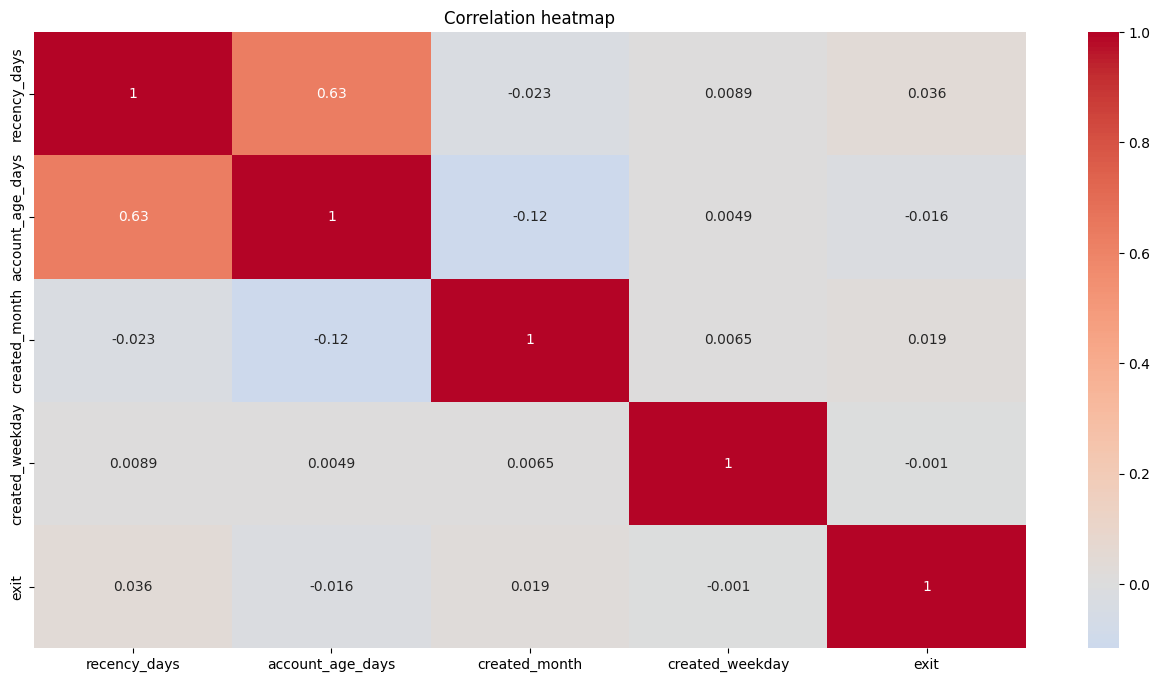

In [170]:
new_cols = ['recency_days', 'account_age_days', 'created_month', 'created_weekday']
corr = df[new_cols + [target]].corr()

plt.figure(figsize=(16, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation heatmap')
plt.show()

In [171]:
# Drop not essential columns
df = df.drop(['last_active_date', 'created_date', 'origin_province', 'profession', 'customer_segment', 'account_age_days', 'created_month', 'created_weekday'], axis=1)

In [172]:
df.to_csv('../data/cleaned.csv')

### Feature Selection & data spplitting

In [173]:
# Drop the target variable 'Churn' from the features and assign it to variable X
X = df.drop('exit', axis=1)

# Assign the target variable 'exit' to y
y = df['exit']

In [174]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify= y)

In [175]:
print("Dataset Split:")
print("=" * 50)
print(f"Training set:   {X_train.shape[0]:6,} samples ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"Test set:       {X_test.shape[0]:6,} samples ({X_test.shape[0]/len(X)*100:.1f}%)")

print("\nClass distribution (% positive):")
print(f"  Training:   {y_train.mean()*100:.2f}%")
print(f"  Test:       {y_test.mean()*100:.2f}%")

Dataset Split:
Training set:   64,000 samples (80.0%)
Test set:       16,000 samples (20.0%)

Class distribution (% positive):
  Training:   18.00%
  Test:       18.00%


Encode categoric and scale numeric features

In [176]:
# Identify numeric and categoric features
numeric_columns = X_train.select_dtypes(include = 'int').columns.tolist()
categoric_columns = X_train.select_dtypes(exclude = 'int').columns.tolist()

print("Feature Type Summary:")
print("=" * 50)
print(f"Numerical features ({len(numeric_columns)}): {numeric_columns}")
print(f"Categorical features({len(categoric_columns)}): {categoric_columns}")

Feature Type Summary:
Numerical features (10): ['credit_score', 'age', 'monthly_income', 'tenure_yearly', 'married', 'nums_card', 'nums_service', 'active_member', 'digital_behavior', 'recency_days']
Categorical features(2): ['balance', 'account_age_groups']


In [177]:
# Create a ColumnTransformer to apply StandardScaler to numerical columns and OneHotEncoder to categorical columns
encoder = OneHotEncoder(drop= 'first')
scaler = StandardScaler()
pipeline = ColumnTransformer(
    transformers=[
        ('encoder', encoder, categoric_columns),
        ('scalar', scaler, numeric_columns)
])

X_train_scaled = pipeline.fit_transform(X_train)
X_test = pipeline.transform(X_test)

ValueError: Found unknown categories [np.float64(13.096967617663932), np.float64(13.288238767680117), np.float64(13.319415898798278), np.float64(13.450078813488757), np.float64(13.517709460431254), np.float64(13.533383693399504), np.float64(13.538210406385605), np.float64(13.633770432106587), np.float64(13.648144606493892), np.float64(13.705301641114945), np.float64(13.728595539968332), np.float64(13.78866645758299), np.float64(13.79266456432315), np.float64(13.796404188224537), np.float64(13.908802338534281), np.float64(13.917882111120873), np.float64(13.959138929104512), np.float64(13.967580789444593), np.float64(13.987857533611024), np.float64(13.99678740256977), np.float64(14.014812134792914), np.float64(14.018559967496085), np.float64(14.0234933637599), np.float64(14.05431641254411), np.float64(14.057299989369135), np.float64(14.074746858526353), np.float64(14.086467796849783), np.float64(14.101515474776471), np.float64(14.101585339415639), np.float64(14.10381243829546), np.float6

In [ ]:
print(pipeline.feature_names_in_)
# or
print(X_train.columns.tolist())

['credit_score' 'age' 'monthly_income' 'tenure_yearly' 'married'
 'nums_card' 'nums_service' 'active_member' 'digital_behavior'
 'recency_days' 'account_age_groups']
['credit_score', 'age', 'monthly_income', 'tenure_yearly', 'married', 'nums_card', 'nums_service', 'active_member', 'digital_behavior', 'recency_days', 'account_age_groups']


## Model Training

### Model Selection

In [ ]:
# Create model dictionary for models
models = {
    'Logistic Regression': LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200,
        class_weight='balanced',
        random_state=42,
        n_jobs=-1
    ),
    'XGBoost': XGBClassifier(
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        n_estimators=200,
        learning_rate=0.05,
        random_state=42,
        eval_metric='logloss',
        verbosity=0
    ),
    'Neural Network': MLPClassifier(
        hidden_layer_sizes=(64, 32, 16),
        activation='relu',
        max_iter=300,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=42
    )
}

### Fit models, predict and append results to result dictionary

In [ ]:
# Train + Evaluate
results = {}

for name, model in models.items():
    print(f"\nTraining: {name}...")
    
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred      = model.predict(X_test)
    y_pred_prob = model.predict_proba(X_test)[:, 1]
    
    # Metrics
    results[name] = {
        'model':     model,
        'y_pred':    y_pred,
        'y_prob':    y_pred_prob,
        'roc_auc':   roc_auc_score(y_test, y_pred_prob),
        'f1':        f1_score(y_test, y_pred, average='binary'),
        'f1_churn':  f1_score(y_test, y_pred, pos_label=1),
        'recall':    classification_report(y_test, y_pred, 
                         output_dict=True)['1']['recall'],
        'precision': classification_report(y_test, y_pred, 
                         output_dict=True)['1']['precision'],
    }
    
    print(f"  ROC-AUC:      {results[name]['roc_auc']:.4f}")
    print(f"  F1 (churn):   {results[name]['f1_churn']:.4f}")
    print(f"  Recall:       {results[name]['recall']:.4f}")
    print(f"  Precision:    {results[name]['precision']:.4f}")


Training: Logistic Regression...
  ROC-AUC:      0.8525
  F1 (churn):   0.5301
  Recall:       0.8382
  Precision:    0.3877

Training: Random Forest...
  ROC-AUC:      0.8391
  F1 (churn):   0.3538
  Recall:       0.2566
  Precision:    0.5698

Training: XGBoost...
  ROC-AUC:      0.8504
  F1 (churn):   0.5277
  Recall:       0.8309
  Precision:    0.3867

Training: Neural Network...
  ROC-AUC:      0.8451
  F1 (churn):   0.4406
  Recall:       0.3656
  Precision:    0.5542


In [ ]:
# Comparison for models
comparison = pd.DataFrame({
    name: {
        'ROC-AUC':   f"{v['roc_auc']:.4f}",
        'F1-churn':  f"{v['f1_churn']:.4f}",
        'Recall':    f"{v['recall']:.4f}",
        'Precision': f"{v['precision']:.4f}",
    }
    for name, v in results.items()
}).T.sort_values('ROC-AUC', ascending=False)

print("\n=== Model Comparison ===")
print(comparison)


=== Model Comparison ===
                    ROC-AUC F1-churn  Recall Precision
Logistic Regression  0.8525   0.5301  0.8382    0.3877
XGBoost              0.8504   0.5277  0.8309    0.3867
Neural Network       0.8451   0.4406  0.3656    0.5542
Random Forest        0.8391   0.3538  0.2566    0.5698


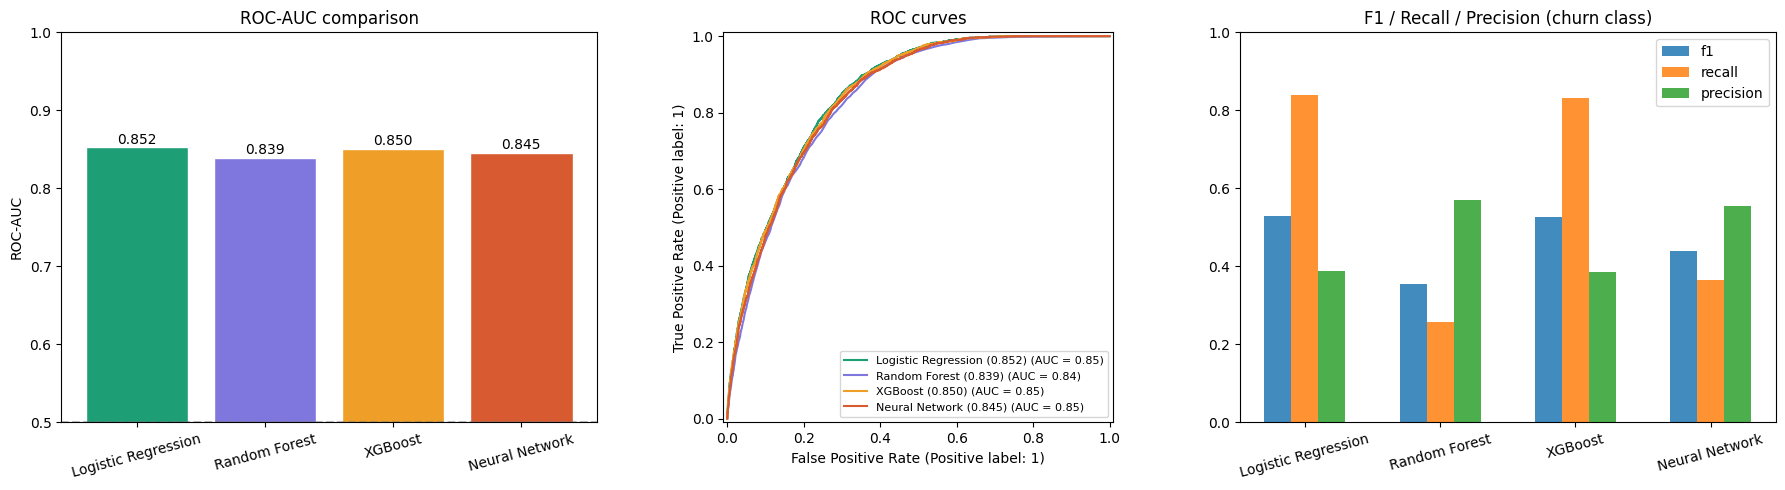

In [ ]:
# Visualizations
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

colors = ['#1D9E75', '#7F77DD', '#EF9F27', '#D85A30']

# ROC-AUC bar chart
names  = list(results.keys())
aucs   = [results[n]['roc_auc'] for n in names]
bars   = axes[0].bar(names, aucs, color=colors, edgecolor='white')
axes[0].set_ylim(0.5, 1.0)
axes[0].set_title('ROC-AUC comparison')
axes[0].set_ylabel('ROC-AUC')
axes[0].axhline(0.5, color='gray', linestyle='--', alpha=0.5, label='Baseline')
for bar, val in zip(bars, aucs):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.005,
                 f'{val:.3f}', ha='center', fontsize=10)
axes[0].tick_params(axis='x', rotation=15)

# ROC Curves
for (name, v), color in zip(results.items(), colors):
    RocCurveDisplay.from_predictions(
        y_test, v['y_prob'],
        name=f"{name} ({v['roc_auc']:.3f})",
        ax=axes[1], color=color
    )
axes[1].set_title('ROC curves')
axes[1].legend(fontsize=8)

# F1 / Recall / Precision
metrics    = ['f1_churn', 'recall', 'precision']
bar_width  = 0.2
x          = np.arange(len(names))
for i, metric in enumerate(metrics):
    vals = [results[n][metric] for n in names]
    axes[2].bar(x + i * bar_width, vals, bar_width,
                label=metric.replace('_churn', ''), alpha=0.85)
axes[2].set_xticks(x + bar_width)
axes[2].set_xticklabels(names, rotation=15)
axes[2].set_title('F1 / Recall / Precision (churn class)')
axes[2].legend()
axes[2].set_ylim(0, 1)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Choose Best Model
best_name  = max(results, key=lambda n: results[n]['roc_auc'])
best_model = results[best_name]['model']
print(f"\nBest model: {best_name}")
print(f"ROC-AUC: {results[best_name]['roc_auc']:.4f}")


Best model: Logistic Regression
ROC-AUC: 0.8525


In [ ]:
from sklearn.metrics import classification_report

# Find thresold for Logistic Regression
y_prob = results['Logistic Regression']['y_prob']

for threshold in [0.5, 0.4, 0.3, 0.2]:
    y_pred_t = (y_prob >= threshold).astype(int)
    report   = classification_report(y_test, y_pred_t, 
                                     output_dict=True)
    recall    = report['1']['recall']
    precision = report['1']['precision']
    f1        = report['1']['f1-score']
    print(f"Threshold {threshold}: Recall={recall:.3f}  "
          f"Precision={precision:.3f}  F1={f1:.3f}")

Threshold 0.5: Recall=0.838  Precision=0.388  F1=0.530
Threshold 0.4: Recall=0.905  Precision=0.350  F1=0.505
Threshold 0.3: Recall=0.949  Precision=0.316  F1=0.474
Threshold 0.2: Recall=0.983  Precision=0.286  F1=0.444


# Save Model, Scaler, Encoder and threshold

In [ ]:
THRESHOLD = 0.3

# Final test result
y_final = (results['Logistic Regression']['y_prob'] >= THRESHOLD).astype(int)
print(classification_report(y_test, y_final, 
      target_names=['Retained', 'Churned']))

# Save it
joblib.dump(best_model, '../model/best_model.pkl')
joblib.dump(pipeline, '../model/pipeline.pkl')
joblib.dump(THRESHOLD, '../model/threshold.pkl')

              precision    recall  f1-score   support

    Retained       0.98      0.55      0.70     13120
     Churned       0.32      0.95      0.47      2880

    accuracy                           0.62     16000
   macro avg       0.65      0.75      0.59     16000
weighted avg       0.86      0.62      0.66     16000



['../model/threshold.pkl']